In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("../DataSets/weatherAUS.csv", encoding="utf-8", usecols=["Date", "Location", "MinTemp", "MaxTemp"])

In [3]:
# Drop records where target MinTemp= Nan or MaxTemp=NaN
df = df.dropna(subset=["MinTemp", "MaxTemp"])

In [4]:
# convert dates to year-months
df["Year-Month"] = (pd.to_datetime(df["Date"], yearfirst=True)).dt.strftime("%Y-%m")

In [5]:
# Derive median daily temperature (mid point between Daily Max and Daily Min)
df["MedTemp"] = df[["MinTemp", "MaxTemp"]].median(axis=1)

In [6]:
df

,Date,Location,MinTemp,MaxTemp,Year-Month,MedTemp
0,2008-12-01,Albury,13.4,22.9,2008-12,18.15
1,2008-12-02,Albury,7.4,25.1,2008-12,16.25
2,2008-12-03,Albury,12.9,25.7,2008-12,19.30
3,2008-12-04,Albury,9.2,28.0,2008-12,18.60
4,2008-12-05,Albury,17.5,32.3,2008-12,24.90
...,...,...,...,...,...,...
145454,2017-06-20,Uluru,3.5,21.8,2017-06,12.65
145455,2017-06-21,Uluru,2.8,23.4,2017-06,13.10
145456,2017-06-22,Uluru,3.6,25.3,2017-06,14.45
145457,2017-06-23,Uluru,5.4,26.9,2017-06,16.15


In [7]:
df2 = df[["Location", "Year-Month", "MedTemp"]].copy()

In [8]:
# Calculate monthly average temperature for each location
df2 = df2.groupby(["Location", "Year-Month"], as_index=False)["MedTemp"].mean()

In [9]:
# Transpose dataframe
# Pivot to wide format
df2_pivot = df2.pivot(index="Location", columns="Year-Month", values="MedTemp")

In [10]:
df2_pivot

Year-Month,2007-11,2007-12,2008-01,2008-02,2008-03,2008-04,2008-05,2008-06,2008-07,2008-08,...,2016-09,2016-10,2016-11,2016-12,2017-01,2017-02,2017-03,2017-04,2017-05,2017-06
Location,,,,,,,,,,,,,,,,,,,,,
Adelaide,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.091935,10.646774,...,13.241667,15.790323,18.413333,22.025806,24.417742,22.844643,23.337097,18.335000,14.290323,11.339583
Albany,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,12.466667,14.232759,16.489286,17.482000,18.256250,18.914000,19.002083,17.250000,15.806897,14.805556
Albury,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,12.213333,13.617742,18.170000,22.677419,25.298387,23.239286,23.067742,15.516667,11.417742,7.972000
AliceSprings,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,17.258333,21.330645,26.291667,28.016129,29.453226,28.676786,28.132258,20.423333,16.474194,10.864583
BadgerysCreek,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,14.766667,17.037097,21.485000,25.065385,26.430645,25.107143,22.050000,17.205000,14.372581,12.766000
Ballarat,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,9.426667,10.600000,13.428333,17.345161,19.833871,17.835714,19.145161,13.046667,9.427419,7.102000
Bendigo,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,11.011667,12.595161,16.818333,21.022581,23.114516,21.066071,22.262903,15.251667,11.029630,8.054000
Brisbane,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.501613,15.274194,...,20.031667,21.098387,24.770000,25.604839,27.188333,27.561111,26.332759,21.363793,19.945161,17.710000
Cairns,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,25.045000,25.574194,27.360000,27.882258,28.412903,28.205357,28.387097,25.845000,24.448387,22.376000


In [11]:
df2_pivot = df2_pivot.drop(
    ["Dartmoor", "Katherine", "Melbourne", "Nhil", "Uluru"],
    axis=0, errors="ignore"
)

In [12]:
df2_pivot.columns

Index(['2007-11', '2007-12', '2008-01', '2008-02', '2008-03', '2008-04',
       '2008-05', '2008-06', '2008-07', '2008-08',
       ...
       '2016-09', '2016-10', '2016-11', '2016-12', '2017-01', '2017-02',
       '2017-03', '2017-04', '2017-05', '2017-06'],
      dtype='object', name='Year-Month', length=113)

In [13]:
# Remove months with lots of missing data (NaN)
df2_pivot=df2_pivot.drop(['2007-11', '2007-12', '2008-01', '2008-02', '2008-03', '2008-04', '2008-05', '2008-06', '2008-07', '2008-08', '2008-09', '2008-10', '2008-11', '2008-12', '2017-01', '2017-02', '2017-03', '2017-04', '2017-05', '2017-06'], axis=1)

In [14]:
df2_pivot

Year-Month,2009-01,2009-02,2009-03,2009-04,2009-05,2009-06,2009-07,2009-08,2009-09,2009-10,...,2016-03,2016-04,2016-05,2016-06,2016-07,2016-08,2016-09,2016-10,2016-11,2016-12
Location,,,,,,,,,,,,,,,,,,,,,
Adelaide,24.967742,25.057143,20.685484,17.908333,14.324194,12.540000,12.388710,13.832258,15.026667,16.708065,...,22.730645,18.708333,16.091935,12.466667,11.696774,12.696774,13.241667,15.790323,18.413333,22.025806
Albany,19.861667,20.150000,18.433871,17.461667,15.417742,13.321667,12.920968,12.988710,12.568333,15.329032,...,19.660345,17.583333,14.827419,13.235000,12.891667,12.590476,12.466667,14.232759,16.489286,17.482000
Albury,25.485484,25.439286,20.535484,15.410000,11.716129,9.206667,8.201613,9.932258,11.951786,14.595161,...,23.290323,17.580000,13.069355,9.500000,9.517742,9.625806,12.213333,13.617742,18.170000,22.677419
AliceSprings,29.240323,28.642857,27.470968,21.181667,14.437097,13.580000,12.933871,19.232258,22.040000,22.020968,...,27.695161,22.403333,18.280645,14.571667,12.816129,14.424194,17.258333,21.330645,26.291667,28.016129
BadgerysCreek,24.467742,22.948214,20.877419,17.305000,14.312903,11.769643,10.727419,12.520968,15.558333,16.646429,...,22.938710,19.743333,15.164516,12.613333,12.053226,11.940323,14.766667,17.037097,21.485000,25.065385
Ballarat,19.498387,19.605357,16.440323,12.175000,10.222581,7.768333,7.108065,8.366129,9.555000,11.288710,...,18.667742,14.500000,11.006452,7.238333,7.224194,7.943548,9.426667,10.600000,13.428333,17.345161
Bendigo,22.995161,22.932143,18.941935,14.511667,12.095161,8.640000,7.837097,9.635484,10.696667,13.859677,...,22.119355,16.440000,12.324194,8.596667,9.111290,9.154839,11.011667,12.595161,16.818333,21.022581
Brisbane,25.720000,25.707143,24.550000,22.611667,19.003226,16.458333,15.783871,18.780645,20.180000,21.729032,...,25.325806,23.663333,21.012903,17.328333,17.361290,17.419355,20.031667,21.098387,24.770000,25.604839
Cairns,27.488710,27.721429,27.400000,26.173333,23.477419,22.780000,21.837097,22.920968,24.815000,25.024194,...,27.882258,26.685000,25.620968,23.741667,23.029032,22.383871,25.045000,25.574194,27.360000,27.882258


In [15]:
# Add missing months 2011-04, 2011-04, 2011-04 and impute data
df2_pivot['2011-04']=(df2_pivot['2011-03']+df2_pivot['2011-05'])/2
df2_pivot['2012-12']=(df2_pivot['2012-11']+df2_pivot['2013-01'])/2
df2_pivot['2013-02']=(df2_pivot['2013-01']+df2_pivot['2013-03'])/2

In [16]:
# Sort columns so Year-Months ar3e in the correct order
df2_pivot = df2_pivot.reindex(sorted(df2_pivot.columns), axis=1)

In [17]:
import plotly.graph_objects as go

In [18]:
# Plot average monthly temperature derived from daily medians for each location
fig = go.Figure()
for location in df2_pivot.index:
    fig.add_trace(go.Scatter(x=df2_pivot.loc[location, :].index,
                             y=df2_pivot.loc[location, :].values,
                             mode='lines', name=location,
                             opacity=0.8, line=dict(width=1)
                            ))

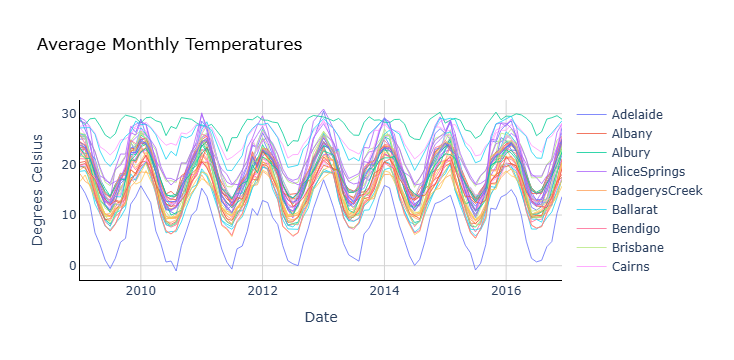

In [19]:
# Change chart background color
fig.update_layout(dict(plot_bgcolor = 'white'), showlegend=True)

# Update axes lines
fig.update_xaxes(showgrid=True, gridwidth=1, gridcolor='lightgrey',
                 zeroline=True, zerolinewidth=1, zerolinecolor='lightgrey',
                 showline=True, linewidth=1, linecolor='black',
                 title='Date'
                )

fig.update_yaxes(showgrid=True, gridwidth=1, gridcolor='lightgrey',
                 zeroline=True, zerolinewidth=1, zerolinecolor='lightgrey',
                 showline=True, linewidth=1, linecolor='black',
                 title='Degrees Celsius'
                )

# Set figure title
fig.update_layout(title=dict(text="Average Monthly Temperatures", font=dict(color='black')))

fig.show()

In [20]:
import numpy as np

In [21]:
def shaping(datain, timestep):
    # Convert input dataframe to array and flatten
    arr = datain.to_numpy().flatten()

    X_list, y_list = [], []
    for i in range(len(datain.columns) - 2 * timestep + 1):
        X_list.append(arr[i:i+timestep])
        y_list.append(arr[i+timestep:i+2*timestep])

    # Reshape input and target arrays
    X_out = np.array(X_list).reshape(-1, timestep, 1)
    y_out = np.array(y_list).reshape(-1, timestep, 1)
    return X_out, y_out

In [22]:
### Step 1 - Specify parameters
timestep = 18
location = "Canberra"

In [23]:
## Step 2 - Prepare data
# Split data into train and test dataframes
df_train = df2_pivot.iloc[:, :-2*timestep].copy()
df_test = df2_pivot.iloc[:, -2*timestep: ].copy()

In [24]:
# Select one location
dfloc_train = df_train[df_train.index==location].copy()
dfloc_test = df_test[df_test.index==location].copy()

In [25]:
# Use previously defined shaping function to reshape the data for LSTM
X_train, y_train = shaping(datain=dfloc_train, timestep=timestep)
X_test, y_test = shaping(datain=dfloc_test, timestep=timestep)

In [26]:
from tensorflow import keras # for building Neural Networks
from keras.models import Sequential # for creating a linear stack of layers for our Neural Network
from keras import Input # for instantiating a keras tensor
from keras.layers import Bidirectional, GRU, RepeatVector, Dense, TimeDistributed # for creating layers inside the Neural Network

In [28]:
model = Sequential(name="GRU-Model1")

# Input Layer
model.add(Input(shape=(X_train.shape[1], X_train.shape[2]), name='Input-Layer'))

# Encoder Layer
model.add(Bidirectional(GRU(units=32, activation='tanh', recurrent_activation='sigmoid', stateful=False), name='Hidden-GRU-Encoder-Layer'))

# Repeat Vector
model.add(RepeatVector(y_train.shape[1], name='Repeat-Vector-Layer'))

# Decoder Layer (Changed from LSTM to GRU)
model.add(Bidirectional(GRU(units=32, activation='tanh', recurrent_activation='sigmoid', stateful=False, return_sequences=True), name='Hidden-GRU-Decoder-Layer'))

# Output Layer
model.add(TimeDistributed(Dense(units=1, activation='linear'), name='Output-Layer'))


In [29]:
##### Step 4 - Compile the model
model.compile(
    optimizer='adam', loss='mean_squared_error',
    metrics=['mean_squared_error', 'mean_absolute_error']
)

In [30]:
history = model.fit(X_train, y_train,
    batch_size=1, epochs=100,
    validation_split=0.2, shuffle=True, verbose=0
)

In [31]:
##### Step 6 - Use model to make predictions
# Predict esults on test data
pred_train = model.predict(X_train)
pred_test = model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


In [32]:
##### Step 7 - Print Performance Summary
print("")
print('-------------------- Model Summary --------------------')
model.summary() # print model summary
print("")
print('-------------------- Weights and Biases --------------------')
print("Too many parameters to print but you can use the code provided if needed")
print("")
for layer in model.layers:
    print(layer.name)
    for item in layer.get_weights():
        print("  ", item)
print("")


-------------------- Model Summary --------------------


Model: "GRU-Model1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Hidden-GRU-Encoder-Layer        │ (None, 64)             │         6,720 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Repeat-Vector-Layer             │ (None, 18, 64)         │             0 │
│ (RepeatVector)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden-GRU-Decoder-Layer        │ (None, 18, 64)         │        18,816 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output-Layer (TimeDistributed)  │ (None, 18, 1)          │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 76,805 (300.02 KB)

 Trainable params: 25,601 (100.00 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 51,204 (200.02 KB)


-------------------- Weights and Biases --------------------
Too many parameters to print but you can use the code provided if needed

Hidden-GRU-Encoder-Layer
   [[ 0.12555858 -0.07769603 -0.0899084   0.09151293  0.25655848  0.26659054
   0.2102071  -0.3664939   0.0911893  -0.05036937  0.07146595  0.11022041
  -0.14148423 -0.03779023  0.02199766 -0.2067537  -0.02252002 -0.20112908
  -0.05960711  0.2865621  -0.06634673 -0.07035861  0.11241746 -0.06546377
   0.2623714  -0.13952023 -0.01648076 -0.22110696 -0.14964093  0.25845495
   0.04163049  0.05631922  0.29433143 -0.05031708 -0.29863912  0.18428703
  -0.03881142 -0.08098276 -0.03102053  0.3169498  -0.27771258  0.09017459
  -0.15752408  0.10316978  0.07256664 -0.22582549 -0.16215442  0.23241971
  -0.25460005 -0.17233686 -0.12289501  0.03837946 -0.12245244  0.22074
  -0.06783738 -0.1618636   0.01200043  0.20376937 -0.15206923  0.21008626
   0.11189565  0.15276806  0.25046188  0.18602578  0.12110579 -0.10526335
  -0.22321779  0.05549956

In [33]:
# Print the last value in the evaluation metrics contained within history file
print('-------------------- Evaluation on Training Data --------------------')
for item in history.history:
    print("Final", item, ":", history.history[item][-1])
print("")

-------------------- Evaluation on Training Data --------------------
Final loss : 1.7687394618988037
Final mean_absolute_error : 1.0626790523529053
Final mean_squared_error : 1.7687394618988037
Final val_loss : 7.488039493560791
Final val_mean_absolute_error : 2.144174575805664
Final val_mean_squared_error : 7.488039493560791



In [34]:
# Evaluate the model on the test data using "evaluate"
print('-------------------- Evaluation on Test Data --------------------')
results = model.evaluate(X_test, y_test)
print("")

-------------------- Evaluation on Test Data --------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 5.0060 - mean_absolute_error: 1.6970 - mean_squared_error: 5.0060



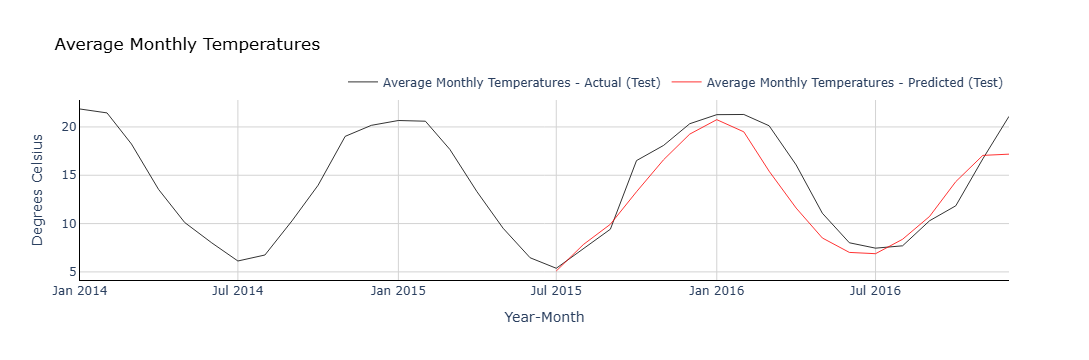

In [35]:
# Plot average monthly temperatures (actual and predicted) for test (out of time) data
fig = go.Figure()

# Trace for actual temperatures
fig.add_trace(go.Scatter(x=np.array(dfloc_test.columns),
                         y=np.array(dfloc_test.values).flatten(),
                         mode='lines',
                         name='Average Monthly Temperatures - Actual (Test)',
                         opacity=0.8,
                         line=dict(color='black', width=1)
                        ))

# Trace for predicted temperatures
fig.add_trace(go.Scatter(x=np.array(dfloc_test.columns[-timestep:]),
                         y=pred_test.flatten(),
                         mode='lines',
                         name='Average Monthly Temperatures - Predicted (Test)',
                         opacity=0.8,
                         line=dict(color='red', width=1)
                        ))

# Change chart background color
fig.update_layout(dict(plot_bgcolor = 'white'))

# Update axes lines
fig.update_xaxes(showgrid=True, gridwidth=1, gridcolor='lightgrey',
                 zeroline=True, zerolinewidth=1, zerolinecolor='lightgrey',
                 showline=True, linewidth=1, linecolor='black',
                 title='Year-Month'
                )

fig.update_yaxes(showgrid=True, gridwidth=1, gridcolor='lightgrey',
                 zeroline=True, zerolinewidth=1, zerolinecolor='lightgrey',
                 showline=True, linewidth=1, linecolor='black',
                 title='Degrees Celsius'
                )

# Set figure title
fig.update_layout(title=dict(text="Average Monthly Temperatures", font=dict(color='black')),
                  legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1)
                 )
fig.show()